## Phase 1/10 — Data Understanding & Initial Project Setup


In [65]:
from pathlib import Path

import numpy as np
import pandas as pd
import re

import warnings
from IPython.display import display

warnings.filterwarnings("ignore")


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

TARGET_COL = 'match_result'
ID_COL = 'match_id'



print("Libraries imported successfully")

Libraries imported successfully


In [66]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'football_data.csv'

print('Project root: ', PROJECT_ROOT)
print('data path: ', DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'dataset file was not found at :\n{DATA_PATH}\n'
        'please make sure football_data.csv is in the project root folder'
    )

Project root:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction
data path:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\football_data.csv


In [67]:
df_raw = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully')
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns")

display(df_raw.head())

Dataset loaded successfully
Shape: 110,938 rows × 190 columns


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [68]:
def normalize_column_name(column_name : str) -> str:
    
    column_name = str(column_name).strip().lower()
    column_name = re.sub(r'[^\w\s]+',' ', column_name)
    column_name = re.sub(r'\s+','_',column_name)
    column_name = re.sub(r'_+','_',column_name)
    column_name = column_name.strip('_')
    return column_name


def make_unique_column_names(columns)->list:
    
    seen = {}
    unique_columns = []
    
    for col in columns:
        base_name = normalize_column_name(col)
        
        
        if base_name not in seen:
            seen[base_name] = 0
            unique_columns.append(base_name)
        else:
            seen[base_name] += 1
            unique_columns.append(f'{base_name}_{seen[base_name]}')
            
    return unique_columns

original_columns = list(df_raw.columns)
normalize_columns = make_unique_column_names(original_columns)


column_mapping = pd.DataFrame({
    'original_columns' : original_columns,
    'normalize_column': normalize_columns
})
df = df_raw.copy()
df.columns = normalize_columns

print('column normalization  completed')
print(f'number of columns : {len(df.columns):,}')

display(column_mapping)

column normalization  completed
number of columns : 190


,original_columns,normalize_column
0,match_id,match_id
1,match_result,match_result
2,home_club,home_club
3,away_club,away_club
4,fixture_date,fixture_date
...,...,...
185,away_club_recent_competition_code_6,away_club_recent_competition_code_6
186,away_club_recent_competition_code_7,away_club_recent_competition_code_7
187,away_club_recent_competition_code_8,away_club_recent_competition_code_8
188,away_club_recent_competition_code_9,away_club_recent_competition_code_9


In [69]:
print('dataset overview')
print('='*60)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns : {df.shape[1]:,}')


print('\nFirst 5 rows')
display(df.head())

print('\nLast 5 rows')
display(df.tail())

print('\nColumn List')
for i,col in enumerate(df.columns,start=1):
        print(f'{i:03d}. {col}')
        

dataset overview
Rows: 110,938
Columns : 190

First 5 rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Last 5 rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Column List
001. match_id
002. match_result
003. home_club
004. away_club
005. fixture_date
006. competition
007. competition_code
008. cup_game
009. home_manager_id
010. away_manager_id
011. home_club_recent_fixture_date_1
012. home_club_recent_fixture_date_2
013. home_club_recent_fixture_date_3
014. home_club_recent_fixture_date_4
015. home_club_recent_fixture_date_5
016. home_club_recent_fixture_date_6
017. home_club_recent_fixture_date_7
018. home_club_recent_fixture_date_8
019. home_club_recent_fixture_date_9
020. home_club_recent_fixture_date_10
021. home_club_recent_played_at_home_1
022. home_club_recent_played_at_home_2
023. home_club_recent_played_at_home_3
024. home_club_recent_played_at_home_4
025. home_club_recent_played_at_home_5
026. home_club_recent_played_at_home_6
027. home_club_recent_played_at_home_7
028. home_club_recent_played_at_home_8
029. home_club_recent_played_at_home_9
030. home_club_recent_played_at_home_10
031. home_club_recent_cup_game_1
032. home_club_re

In [70]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'


MAIN_MATCH_COLUMNS = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cup_game',
    'home_manager_id',
    'away_manager_id'
]


main_columns_status = pd.DataFrame({
    'column': MAIN_MATCH_COLUMNS,
    'exists': [col in df.columns for col in MAIN_MATCH_COLUMNS],
    'dtype': [str(df[col].dtype) if col in df.columns else None for col in MAIN_MATCH_COLUMNS],
    'null_count':[df[col].isna().sum() if col in df.columns else None for col in MAIN_MATCH_COLUMNS],
    'unique_count': [df[col].nunique(dropna=True) if col in df.columns else None for col in MAIN_MATCH_COLUMNS]
})



display(main_columns_status)


missing_main_columns = main_columns_status.loc[
        ~main_columns_status['exists'],
        'column'
].tolist()




if TARGET_COL not in df.columns:
    raise ValueError(
        f'Target column {TARGET_COL} was not found'
        'please check the dataset column name or update TARGET_COL'
    )
    
print(f'target column {TARGET_COL} exists')


if ID_COL in df.columns:
    duplicated_id_count = df[ID_COL].duplicated().sum()
    print(f'duplicated match_id  count: {duplicated_id_count:,}')
    
else:
    print(f'warning : id column {ID_COL} was not found')


print(f'existing main column : {len(MAIN_MATCH_COLUMNS) - len(missing_main_columns)}/{len(MAIN_MATCH_COLUMNS)}')

if missing_main_columns:
    print('\nwarning-> misising main  columns:')
    for col in missing_main_columns:
        print('-',col)

,column,exists,dtype,null_count,unique_count
0,match_id,True,int64,0,110938
1,match_result,True,object,0,3
2,home_club,True,object,1,9813
3,away_club,True,object,1,9892
4,fixture_date,True,object,0,20269
5,competition,True,object,1,727
6,competition_code,True,int64,0,862
7,cup_game,True,object,1,2
8,home_manager_id,True,float64,21721,8804
9,away_manager_id,True,float64,21815,8938


target column match_result exists
duplicated match_id  count: 0
existing main column : 10/10


In [71]:
target_counts = df[TARGET_COL].value_counts(dropna=False)
target_percentage = df[TARGET_COL].value_counts(normalize=True,dropna=False).mul(100)

target_distribution = pd.DataFrame({
    'count': target_counts,
    'percentage' : target_percentage.round(2)
})

print('Target Distribution')
print('-'*60)

display(target_distribution)

print(f'number of target classes: {df[TARGET_COL].nunique(dropna=True)}')

missing_target_count = df[TARGET_COL].isna().sum()


if missing_target_count > 0:
    print(f'warning : target column contians {missing_target_count :,} missing values')

majority_class_percentage =  target_percentage.max()

print(f'Majority class percentage : {majority_class_percentage :.2f}%')

if majority_class_percentage >= 70:
    print('warning : Target distribution seems highly imbalanced')
    
else:
    print('Target distribution does not seem extremely imbalanced')
    

Target Distribution
------------------------------------------------------------


,count,percentage
match_result,,
home,48113,43.37
away,35174,31.71
draw,27651,24.92


number of target classes: 3
Majority class percentage : 43.37%
Target distribution does not seem extremely imbalanced


In [72]:
dtype_summary= pd.DataFrame({
    'column' : df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null_count': df.notna().sum().values,
    'null_count': df.isna().sum().values,
    'null_percentage': df.isna().mean().mul(100).round(2).values,
    'unique_count': [df[col].nunique(dropna=True) for col in df.columns]
})


dtype_summary['unique_percentage'] = (
    dtype_summary['unique_count'] / len(df)*100
).round(2)

dtype_summary = dtype_summary.sort_values(
    ['null_percentage','unique_count'],
    ascending=[False,False]
)

print('column qulity summary - to 50')
display(dtype_summary.head(50))

print('\nDtype counts:')
display(dtype_summary['dtype'].value_counts().to_frame('count'))

print('\nColumns with more than 50% missing values: ')
high_missing_columns = dtype_summary[dtype_summary['null_percentage']>50]

if len(high_missing_columns)> 0:
    display(high_missing_columns)
else:
    print('no columns with more than 50% missing values')

column qulity summary - to 50


,column,dtype,non_null_count,null_count,null_percentage,unique_count,unique_percentage
179,away_club_recent_manager_id_10,float64,83809,27129,24.45,7936,7.15
89,home_club_recent_manager_id_10,float64,84285,26653,24.03,7891,7.11
178,away_club_recent_manager_id_9,float64,84788,26150,23.57,8044,7.25
88,home_club_recent_manager_id_9,float64,85205,25733,23.20,8002,7.21
177,away_club_recent_manager_id_8,float64,85719,25219,22.73,8144,7.34
87,home_club_recent_manager_id_8,float64,86069,24869,22.42,8150,7.35
176,away_club_recent_manager_id_7,float64,86561,24377,21.97,8303,7.48
86,home_club_recent_manager_id_7,float64,86958,23980,21.62,8265,7.45
175,away_club_recent_manager_id_6,float64,87413,23525,21.21,8440,7.61
85,home_club_recent_manager_id_6,float64,87680,23258,20.96,8385,7.56



Dtype counts:


,count
dtype,
float64,162
object,26
int64,2



Columns with more than 50% missing values: 
no columns with more than 50% missing values


In [73]:
date_like_columns = [col for col in df.columns if "date" in col]

print("Detected date-like columns:")
for col in date_like_columns:
    print("-", col)

date_parse_report = []

for col in date_like_columns:
    parsed = pd.to_datetime(df[col], errors="coerce")

    non_null_original = df[col].notna().sum()
    parsed_non_null = parsed.notna().sum()

    if non_null_original > 0:
        parse_success_percentage = parsed_non_null / non_null_original * 100
    else:
        parse_success_percentage = 0

    date_parse_report.append({
        "column": col,
        "original_dtype": str(df[col].dtype),
        "original_non_null_count": non_null_original,
        "parsed_non_null_count": parsed_non_null,
        "parse_success_percentage": round(parse_success_percentage, 2),
        "min_date": parsed.min(),
        "max_date": parsed.max(),
        "null_after_parse": parsed.isna().sum()
    })

date_parse_report = pd.DataFrame(date_parse_report)

display(date_parse_report)

poor_date_parse_columns = date_parse_report[
    date_parse_report["parse_success_percentage"] < 80
]

if len(poor_date_parse_columns) > 0:
    print("\nwarning: Some date-like columns have weak parsing quality:")
    display(poor_date_parse_columns)
else:
    print("\nall detected date-like columns have acceptable parsing quality.")

Detected date-like columns:
- fixture_date
- home_club_recent_fixture_date_1
- home_club_recent_fixture_date_2
- home_club_recent_fixture_date_3
- home_club_recent_fixture_date_4
- home_club_recent_fixture_date_5
- home_club_recent_fixture_date_6
- home_club_recent_fixture_date_7
- home_club_recent_fixture_date_8
- home_club_recent_fixture_date_9
- home_club_recent_fixture_date_10
- away_club_recent_fixture_date_1
- away_club_recent_fixture_date_2
- away_club_recent_fixture_date_3
- away_club_recent_fixture_date_4
- away_club_recent_fixture_date_5
- away_club_recent_fixture_date_6
- away_club_recent_fixture_date_7
- away_club_recent_fixture_date_8
- away_club_recent_fixture_date_9
- away_club_recent_fixture_date_10


,column,original_dtype,original_non_null_count,parsed_non_null_count,parse_success_percentage,min_date,max_date,null_after_parse
0,fixture_date,object,110938,110938,100.0,2019-12-01 00:45:00,2021-05-01 00:00:00,0
1,home_club_recent_fixture_date_1,object,109779,109779,100.0,2019-01-04 14:00:00,2021-04-28 23:00:00,1159
2,home_club_recent_fixture_date_2,object,108487,108487,100.0,2019-01-05 02:30:00,2021-04-25 23:00:00,2451
3,home_club_recent_fixture_date_3,object,107165,107165,100.0,2019-01-03 15:45:00,2021-04-23 23:00:00,3773
4,home_club_recent_fixture_date_4,object,105837,105837,100.0,2019-01-03 15:45:00,2021-04-22 00:00:00,5101
5,home_club_recent_fixture_date_5,object,104461,104461,100.0,2019-01-03 15:45:00,2021-04-18 23:00:00,6477
6,home_club_recent_fixture_date_6,object,103042,103042,100.0,2019-01-04 22:30:00,2021-04-17 01:00:00,7896
7,home_club_recent_fixture_date_7,object,101643,101643,100.0,2019-01-02 16:00:00,2021-04-15 00:30:00,9295
8,home_club_recent_fixture_date_8,object,100219,100219,100.0,2019-01-03 23:30:00,2021-04-08 00:30:00,10719
9,home_club_recent_fixture_date_9,object,98802,98802,100.0,2019-01-02 16:00:00,2021-04-03 14:00:00,12136



all detected date-like columns have acceptable parsing quality.


In [74]:
RECENT_PATTERN = re.compile(r'^(home_club|away_club)_recent_(.+)_(\d+)$')

recent_columns_info = []

for col in df.columns:
    match = RECENT_PATTERN.match(col)
    if match:
        club_side = match.group(1)
        feature_name = match.group(2)
        recent_number = int(match.group(3))
        
        recent_columns_info.append({
            'column':col,
            'club_side':club_side,
            'feature' : feature_name,
            'recent_number': recent_number,
            'dtype': str(df[col].dtype),
            'null_percentage': round(df[col].isna().mean()*100,2),
            'unique_count': df[col].nunique(dropna=True)
        })
        
        
recent_columns_info = pd.DataFrame(recent_columns_info)

print('number of deteceted recent_history columns:',len(recent_columns_info))


if len(recent_columns_info)> 0:
    display(
        recent_columns_info
        .sort_values(['club_side','feature','recent_number'])
        .head(50)
    )
    
    recent_feature_summary = (
        recent_columns_info
        .groupby(['club_side','feature'])
        .agg(
            deteceted_recent_numbers = ('recent_number',lambda x: sorted(x.tolist())),
            deteceted_count=('column','count'),
            min_recent_number =('recent_number','min'),
            max_recent_number = ('recent_number','max'),
            avg_null_percentage = ('null_percentage','mean'),
            avg_unique_count = ('unique_count','mean')
        )
        .reset_index()
    )
    
    recent_feature_summary['avg_null_percentage'] = recent_feature_summary['avg_null_percentage'].round(2)
    recent_feature_summary['avg_unique_count'] = recent_feature_summary['avg_unique_count'].round(2)

    display(recent_feature_summary)
    
else:
    print('no recent-history columns were detected please check columns names')

number of deteceted recent_history columns: 180


,column,club_side,feature,recent_number,dtype,null_percentage,unique_count
170,away_club_recent_competition_code_1,away_club,competition_code,1,float64,1.11,864
171,away_club_recent_competition_code_2,away_club,competition_code,2,float64,2.34,856
172,away_club_recent_competition_code_3,away_club,competition_code,3,float64,3.64,854
173,away_club_recent_competition_code_4,away_club,competition_code,4,float64,4.97,850
174,away_club_recent_competition_code_5,away_club,competition_code,5,float64,6.31,836
175,away_club_recent_competition_code_6,away_club,competition_code,6,float64,7.60,828
176,away_club_recent_competition_code_7,away_club,competition_code,7,float64,8.89,821
177,away_club_recent_competition_code_8,away_club,competition_code,8,float64,10.18,808
178,away_club_recent_competition_code_9,away_club,competition_code,9,float64,11.50,791
179,away_club_recent_competition_code_10,away_club,competition_code,10,float64,12.81,777


,club_side,feature,deteceted_recent_numbers,deteceted_count,min_recent_number,max_recent_number,avg_null_percentage,avg_unique_count
0,away_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,828.5
1,away_club,cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,7.22,2.0
2,away_club,fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,19651.7
3,away_club,goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,15.6
4,away_club,goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,16.9
5,away_club,manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,21.35,8485.7
6,away_club,opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,97015.8
7,away_club,played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,2.0
8,away_club,team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,97057.5
9,home_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.54,831.3


In [75]:
expected_recent_numbers = set(range(1,11))

recent_structure_checks = []

if 'recent_columns_info' in globals() and len(recent_columns_info) > 0:
    for (club_side,feature) , group in recent_columns_info.groupby(['club_side','feature']):
        deteceted_numbers =  set(group['recent_number'].tolist())
        
        
        missing_numbers = sorted(expected_recent_numbers - deteceted_numbers)
        extra_numbers = sorted(deteceted_numbers - expected_recent_numbers)
        
        
        recent_structure_checks.append({
            'club_side': club_side,
            'feature': feature,
            'expected_numbers': sorted(expected_recent_numbers),
            'detected_numbers': sorted(deteceted_numbers),
            'detected_count': len(deteceted_numbers),
            'missing_numbers': missing_numbers,
            'extra_numbers': extra_numbers,
            'is_complete_1_to_10': len(missing_numbers) == 0 and len(extra_numbers) == 0
        })
        

recent_structure_checks = pd.DataFrame(recent_structure_checks)

print('recent_history structure check')
print('-'*60)


if len(recent_structure_checks)> 0:
    display(recent_columns_info)
    
    
    incomplete_recent_features = recent_structure_checks[
        ~recent_structure_checks['is_complete_1_to_10']
    ]
    
    if len(incomplete_recent_features) == 0:
        print('all detected recent-history features  have complete numbers from 1 to 10')
    else:
        print('warning : some recent-history features are in incomplete_recent_features')
        display(incomplete_recent_features)
else:
    print('no recent-history structure was checked beacuse no recent-history columns were detected')

recent_history structure check
------------------------------------------------------------


,column,club_side,feature,recent_number,dtype,null_percentage,unique_count
0,home_club_recent_fixture_date_1,home_club,fixture_date,1,object,1.04,19552
1,home_club_recent_fixture_date_2,home_club,fixture_date,2,object,2.21,19543
2,home_club_recent_fixture_date_3,home_club,fixture_date,3,object,3.40,19646
3,home_club_recent_fixture_date_4,home_club,fixture_date,4,object,4.60,19763
4,home_club_recent_fixture_date_5,home_club,fixture_date,5,object,5.84,19850
...,...,...,...,...,...,...,...
175,away_club_recent_competition_code_6,away_club,competition_code,6,float64,7.60,828
176,away_club_recent_competition_code_7,away_club,competition_code,7,float64,8.89,821
177,away_club_recent_competition_code_8,away_club,competition_code,8,float64,10.18,808
178,away_club_recent_competition_code_9,away_club,competition_code,9,float64,11.50,791


all detected recent-history features  have complete numbers from 1 to 10


In [76]:
full_duplicate_count = df.duplicated().sum()
full_duplicate_percentage = full_duplicate_count / len(df)*100

print('duplicate records check')
print('-'*60)


print(f'fully duplicated rows : {full_duplicate_count:,}')
print(f'fully duplicate rows percentage : {full_duplicate_percentage:.2f}%')


duplicated_match_id_count = None
missing_match_id_count = None

if ID_COL in df.columns:
    missing_match_id_count = df[ID_COL].isna().sum()
    
    non_null_id_mask = df[ID_COL].notna()
    duplicated_match_id_count = df.loc[non_null_id_mask,ID_COL].duplicated().sum()
    
    
    print(f'\nmissing {ID_COL} values : {missing_match_id_count:,}')
    print(f'duplicate non-null {ID_COL} values: {duplicated_match_id_count: ,}')
    
    
    if duplicated_match_id_count > 0:
        duplicated_ids_preview  = (
            df[df[ID_COL].notna() & df[ID_COL].duplicated(keep=False)]
            .sort_values(ID_COL)
            .head(20)
        )
        
        print('\n preview of duplicated match_id records: ')
        display(duplicated_ids_preview)
        
        
        duplicated_id_summary = (
            df.loc[df[ID_COL].notna(),ID_COL]
            .value_counts()
            .loc[lambda x: x>1]
            .reset_index()
        )
        
        
        duplicated_id_summary.columns = [ID_COL,'duplicate_count']
        
        print('\n duplicated match_id summary')
        display(duplicated_id_summary.head(20))
        
else:
    print(f'\ncolumn {ID_COL} not found skipping match_id duplicate check')

duplicate records check
------------------------------------------------------------
fully duplicated rows : 0
fully duplicate rows percentage : 0.00%

missing match_id values : 0
duplicate non-null match_id values:  0


In [77]:
missing_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_percentage': df.isna().mean().mul(100).round(2).values,
    'non_missing_count': df.notna().sum().values,
    'unique_count': [df[col].nunique(dropna=True) for col in df.columns]
})


missing_summary['missing_level'] = pd.cut(
    missing_summary['missing_percentage'],
    bins = [-0.01,0,10,30,50,100],
    labels = ['none','low','medium','high','very_high']
)


missing_summary = missing_summary.sort_values(
    ['missing_percentage','unique_count'],
    ascending=[False,False]
)

print('missing values summary')
print('-'*60)

print('top column by missing percentage')
display(missing_summary.head(50))


columns_with_missing = missing_summary[missing_summary['missing_count']>0]
high_missing_columns = missing_summary[missing_summary["missing_percentage"] > 50]

print(f'\ncolumns with at least one missing value : {len(columns_with_missing):,}/{df.shape[1]:,}')
print(f'columns with more than 50% missing values :{len(high_missing_columns):,}')


if len(high_missing_columns)>0:
    display(high_missing_columns)
    
    
row_missing_summary = pd.DataFrame({
    'row_missing_count': df.isna().sum(axis=1),
    'row_missing_percentage': df.isna().mean(axis=1).mul(100).round(2)
})

print('\n row level missingness:')
display(row_missing_summary.describe().T)

missing values summary
------------------------------------------------------------
top column by missing percentage


,column,dtype,missing_count,missing_percentage,non_missing_count,unique_count,missing_level
179,away_club_recent_manager_id_10,float64,27129,24.45,83809,7936,medium
89,home_club_recent_manager_id_10,float64,26653,24.03,84285,7891,medium
178,away_club_recent_manager_id_9,float64,26150,23.57,84788,8044,medium
88,home_club_recent_manager_id_9,float64,25733,23.20,85205,8002,medium
177,away_club_recent_manager_id_8,float64,25219,22.73,85719,8144,medium
87,home_club_recent_manager_id_8,float64,24869,22.42,86069,8150,medium
176,away_club_recent_manager_id_7,float64,24377,21.97,86561,8303,medium
86,home_club_recent_manager_id_7,float64,23980,21.62,86958,8265,medium
175,away_club_recent_manager_id_6,float64,23525,21.21,87413,8440,medium
85,home_club_recent_manager_id_6,float64,23258,20.96,87680,8385,medium



columns with at least one missing value : 186/190
columns with more than 50% missing values :0

 row level missingness:


,count,mean,std,min,25%,50%,75%,max
row_missing_count,110938.0,15.479421,33.954936,0.0,0.0,0.0,11.00,182.00
row_missing_percentage,110938.0,8.147255,17.870966,0.0,0.0,0.0,5.79,95.79


In [78]:
categorical_keywrods = [
    'club',
    'competition',
    'manager',
    'result',
    'code',
    'cup_game',
    'played_at_home'
]

possible_categorical_columns = []

for col in df.columns:
    is_object_or_category = df[col].dtype == 'object' or str(df[col].dtype) == 'category'
    
    is_boolean = df[col].dtype =='bool'
    has_categorical_keyword = any(keyword in col for keyword in categorical_keywrods)
    
    if is_object_or_category or is_boolean or has_categorical_keyword:
        possible_categorical_columns.append(col)
        
possible_categorical_columns = sorted(set(possible_categorical_columns))

categorical_cardinality = pd.DataFrame({
    'column': possible_categorical_columns,
    'dtype': [str(df[col].dtype) for col in possible_categorical_columns],
    'unique_count': [df[col].nunique(dropna=True) for col in possible_categorical_columns],
    'missing_percentage': [round(df[col].isna().mean()*100,2) for col in possible_categorical_columns],
    'sample_values':[
        df[col].dropna().astype(str).unique()[:5].tolist()
        for col in possible_categorical_columns
    ]
})


categorical_cardinality['unique_percentage'] = (
    categorical_cardinality["unique_count"] / len(df) * 100
).round(2)

categorical_cardinality['cardinality_level'] = pd.cut(
    categorical_cardinality['unique_count'],
    bins = [-1,2,10,50,200,np.inf],
    labels=['binary','low','medium','high','very_high']
)

categorical_cardinality = categorical_cardinality.sort_values(
    ['unique_count','missing_percentage'],
    ascending=[False,False],
)

print('categorical cardinality summary')
print('-'*60)

display(categorical_cardinality.head(50))

high_cardinality_columns  = categorical_cardinality[
    categorical_cardinality["cardinality_level"].isin(["high", "very_high"])
]

print(f'\n possible categorical columns: {len(possible_categorical_columns):,}')
print(f'high-cardinality categorical columns: {len(high_cardinality_columns):,}')

if len(high_cardinality_columns)>0:
    display(high_cardinality_columns)

categorical cardinality summary
------------------------------------------------------------


,column,dtype,unique_count,missing_percentage,sample_values,unique_percentage,cardinality_level
157,home_club_recent_opponent_rating_1,float64,103250,1.06,"[5.19984, 3.67161, 6.82519375, 5.998799999999999, 5.535514285714286]",93.07,very_high
81,away_club_recent_team_rating_1,float64,103200,1.12,"[4.598, 6.000587500000001, 8.37941875, 5.998799999999999, 6.34939]",93.02,very_high
177,home_club_recent_team_rating_1,float64,103169,1.06,"[3.85686, 13.668799999999996, 5.73671875, 5.998799999999999, 6.295742857142858]",93.00,very_high
61,away_club_recent_opponent_rating_1,float64,103089,1.12,"[5.2532250000000005, 6.881762499999999, 5.487337500000001, 5.998799999999999, 5.57518]",92.92,very_high
179,home_club_recent_team_rating_2,float64,101900,2.22,"[5.72437, 5.967622222222223, 9.745283333333331, 5.860495833333333, 7.625358333333333]",91.85,very_high
159,home_club_recent_opponent_rating_2,float64,101841,2.22,"[3.6940333333333335, 6.1212277777777775, 4.053166666666667, 6.024041666666666, 4.848224999999999]",91.80,very_high
63,away_club_recent_opponent_rating_2,float64,101786,2.35,"[2.8199625, 6.840557692307692, 7.6977125, 6.548433333333334, 5.901841666666668]",91.75,very_high
83,away_club_recent_team_rating_2,float64,101757,2.35,"[11.825566666666669, 4.692007692307692, 4.8501, 4.901579166666666, 5.8947]",91.72,very_high
180,home_club_recent_team_rating_3,float64,100658,3.41,"[4.335090624999999, 9.13061111111111, 5.685919999999999, 8.2569, 5.320905555555555]",90.73,very_high
160,home_club_recent_opponent_rating_3,float64,100641,3.41,"[5.13115625, 3.3204499999999992, 5.293940000000001, 4.508125, 6.279472222222222]",90.72,very_high



 possible categorical columns: 189
high-cardinality categorical columns: 107


,column,dtype,unique_count,missing_percentage,sample_values,unique_percentage,cardinality_level
157,home_club_recent_opponent_rating_1,float64,103250,1.06,"[5.19984, 3.67161, 6.82519375, 5.998799999999999, 5.535514285714286]",93.07,very_high
81,away_club_recent_team_rating_1,float64,103200,1.12,"[4.598, 6.000587500000001, 8.37941875, 5.998799999999999, 6.34939]",93.02,very_high
177,home_club_recent_team_rating_1,float64,103169,1.06,"[3.85686, 13.668799999999996, 5.73671875, 5.998799999999999, 6.295742857142858]",93.00,very_high
61,away_club_recent_opponent_rating_1,float64,103089,1.12,"[5.2532250000000005, 6.881762499999999, 5.487337500000001, 5.998799999999999, 5.57518]",92.92,very_high
179,home_club_recent_team_rating_2,float64,101900,2.22,"[5.72437, 5.967622222222223, 9.745283333333331, 5.860495833333333, 7.625358333333333]",91.85,very_high
...,...,...,...,...,...,...,...
10,away_club_recent_competition_code_9,float64,791,11.50,"[636.0, 752.0, 734.0, 746.0, 705.0]",0.71,very_high
106,home_club_recent_competition_code_9,float64,791,10.94,"[636.0, 752.0, 734.0, 743.0, 705.0]",0.71,very_high
98,home_club_recent_competition_code_10,float64,784,12.22,"[636.0, 752.0, 734.0, 743.0, 705.0]",0.71,very_high
2,away_club_recent_competition_code_10,float64,777,12.81,"[1122.0, 752.0, 734.0, 743.0, 705.0]",0.70,very_high


In [79]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print('numeric columns summary')
print('-'*60)


print(f'number of numeric columns: {len(numeric_columns):,}')


if numeric_columns:
    numeric_description = df[numeric_columns].describe().T.reset_index()
    numeric_description = numeric_description.rename(columns={'index':'column'})
    
    
    numeric_description['missing_percentage'] = (
        df[numeric_columns].isna().mean().mul(100).round(2).values
    )
    numeric_description['negative_count'] = [
        (df[col]<0).sum() for col in numeric_columns
    ]
    
    display(numeric_description.head(30))
    
    constant_numeric_columns = [
        col for col in numeric_columns
        if df[col].nunique(dropna=True) <=1 
    ]
    print(f'\n constant or near-empty numeric columns:{len(constant_numeric_columns):,}')
    
    
    if  constant_numeric_columns:
        print(constant_numeric_columns)
        
else:
    print('no numeric columns detected')

numeric columns summary
------------------------------------------------------------
number of numeric columns: 164


,column,count,mean,std,min,25%,50%,75%,max,missing_percentage,negative_count
0,match_id,110938.0,1.519875e+07,2.536393e+06,11428294.0,12000376.25,16759881.5,17242303.75,18053837.0,0.00,0
1,competition_code,110938.0,9.104570e+02,5.491210e+02,2.0,444.00,947.0,1293.00,2039.0,0.00,0
2,home_manager_id,89217.0,1.287134e+07,1.578479e+07,2.0,459612.00,1552728.0,32431162.00,37568493.0,19.58,0
3,away_manager_id,89123.0,1.291552e+07,1.580344e+07,2.0,459565.00,1552806.0,32795385.50,37568466.0,19.66,0
4,home_club_recent_played_at_home_1,109779.0,3.069440e-01,4.612280e-01,0.0,0.00,0.0,1.00,1.0,1.04,0
5,home_club_recent_played_at_home_2,108487.0,5.678008e-01,4.953840e-01,0.0,0.00,1.0,1.00,1.0,2.21,0
6,home_club_recent_played_at_home_3,107165.0,4.661410e-01,4.988546e-01,0.0,0.00,0.0,1.00,1.0,3.40,0
7,home_club_recent_played_at_home_4,105837.0,5.194686e-01,4.996232e-01,0.0,0.00,1.0,1.00,1.0,4.60,0
8,home_club_recent_played_at_home_5,104461.0,4.878567e-01,4.998549e-01,0.0,0.00,0.0,1.00,1.0,5.84,0
9,home_club_recent_played_at_home_6,103042.0,5.072883e-01,4.999493e-01,0.0,0.00,1.0,1.00,1.0,7.12,0



 constant or near-empty numeric columns:0


In [80]:
leakage_suspicious_keywords = [
    'result',
    'final',
    'score',
    'winner',
    'outcome',
    'home_goals',
    'away_goals',
    'full_time',
    'half_time',
    'ft_',
    'ht_'
]

leakage_report = []

for col in df.columns:
    col_lower = col.lower()
    
    
    if col == TARGET_COL:
        continue
    
    
    matched_keywords = [
        keyword for keyword in leakage_suspicious_keywords
        if keyword in col_lower
    ]
    
    
    if not matched_keywords:
        continue
    
    is_recent_history_column  = bool(RECENT_PATTERN.match(col)) if 'RECENT_PATTERN' in globals() else False
    
    
    if is_recent_history_column  :
        leakage_risk  = 'low'
        reason = 'column appears to describe previous matches not the current match result'
        
    else:
        leakage_risk  = 'high'
        reason = 'column name may contain post-match information or target-related information'
        

    leakage_report.append({
        "column": col,
        "matched_keywords": matched_keywords,
        "is_recent_history_column": is_recent_history_column,
        "leakage_risk": leakage_risk,
        "reason": reason
    })

    
leakage_report = pd.DataFrame(leakage_report)

print('potential data leakage check')
print('-'*60)


if len(leakage_report)>0:
    display(leakage_report.sort_values(['leakage_risk','column'],ascending=[True,True]))
    
    high_risk_leakage_columns = leakage_report[
        leakage_report['leakage_risk'] == 'high'
    ]['column'].tolist()
    
    
    if high_risk_leakage_columns:
        print('\nhigh-risk suspicious columns:')
        for col in high_risk_leakage_columns:
            print('-',col)
            
    else:
        print('\n no high-risk leakage columns detected')
        
else:
    high_risk_leakage_columns = []
    print('no obvious suspicious leakage columns detected based on keyword rules')
    
print('\nImportant')
print('this is keyword-based leakage check .final leakage validation  must be done before modeling')

potential data leakage check
------------------------------------------------------------


,column,matched_keywords,is_recent_history_column,leakage_risk,reason
10,away_club_recent_goals_scored_1,[score],True,low,column appears to describe previous matches not the current match result
19,away_club_recent_goals_scored_10,[score],True,low,column appears to describe previous matches not the current match result
11,away_club_recent_goals_scored_2,[score],True,low,column appears to describe previous matches not the current match result
12,away_club_recent_goals_scored_3,[score],True,low,column appears to describe previous matches not the current match result
13,away_club_recent_goals_scored_4,[score],True,low,column appears to describe previous matches not the current match result
14,away_club_recent_goals_scored_5,[score],True,low,column appears to describe previous matches not the current match result
15,away_club_recent_goals_scored_6,[score],True,low,column appears to describe previous matches not the current match result
16,away_club_recent_goals_scored_7,[score],True,low,column appears to describe previous matches not the current match result
17,away_club_recent_goals_scored_8,[score],True,low,column appears to describe previous matches not the current match result
18,away_club_recent_goals_scored_9,[score],True,low,column appears to describe previous matches not the current match result



 no high-risk leakage columns detected

Important
this is keyword-based leakage check .final leakage validation  must be done before modeling


In [81]:
import json

existing_main_columns = [col for col in MAIN_MATCH_COLUMNS  if col in df.columns]
missing_main_columns = [col for col in MAIN_MATCH_COLUMNS  if col not in df.columns]


target_distribution_dict = (
    target_distribution.reset_index().rename(columns={'index':'class'}).to_dict(orient='records')
    if 'target_distribution' in globals()
    else []
    
)


phase_1_summary = {
    'dataset_path' : str(DATA_PATH),
    'n_rows':int(df.shape[0]),
    'n_columns': int(df.shape[1]),
    
    
    'target_column' : TARGET_COL,
    'target_exists': TARGET_COL in df.columns,
    'n_target_classes' : int(df[TARGET_COL].nunique(dropna=True)) if TARGET_COL in df.columns else None,
    'target_missing_count': int(df[TARGET_COL].isna().sum()) if TARGET_COL in df.columns else None,
    'target_distribution': target_distribution_dict,
    
    'id_column': ID_COL,
    'id_exists': ID_COL in df.columns,
    'missing_match_id_count' : int(missing_match_id_count) if missing_match_id_count is not None else None,
    'duplicated_match_id_count': int(duplicated_match_id_count) if duplicated_match_id_count is not None else None,
    
    'main_columns_existing': existing_main_columns,
    'main_columns_missing': missing_main_columns,
    
    
    'full_duplicate_rows': int(full_duplicate_count),
    'full_duplicate_percentage': round(float(full_duplicate_percentage),2),
    
    
    "columns_with_missing_count": int(len(columns_with_missing)) if "columns_with_missing" in globals() else None,
    'high_missing_columns_count': int(len(high_missing_columns)) if 'high_missing_columns' in globals() else None,
    
    
    'numeric_columns_count': int(len(numeric_columns)) if 'numeric_columns' in globals() else None,
    'possible_categorical_columns_count': int(len(possible_categorical_columns)) if 'possible_categorical_columns' in globals() else None,
    
    
    'recent_history_columns_detected': int(len(recent_columns_info)) if 'recent_columns_info' in globals() else 0, 
    
    'recent_history_incomplete_feature_count' : int(len(incomplete_recent_features)) if 'incomplete_recent_features' in globals() else None,
    
    'date_like_columns_detected' : date_like_columns if 'date_like_columns' in globals() else [],
    
    'high_risk_suspicious_leakage_columns' : high_risk_leakage_columns if 'high_risk_leakage_columns' in globals() else []
    
      
}

print('Phase  One summary')
print('*'*60)

print(json.dumps(phase_1_summary,indent=4,ensure_ascii=False,default=str))

Phase  One summary
************************************************************
{
    "dataset_path": "c:\\Users\\mojta_tok6stl\\OneDrive\\Desktop\\learning_ai\\Football_Match_Prediction\\football_data.csv",
    "n_rows": 110938,
    "n_columns": 190,
    "target_column": "match_result",
    "target_exists": true,
    "n_target_classes": 3,
    "target_missing_count": 0,
    "target_distribution": [
        {
            "match_result": "home",
            "count": 48113,
            "percentage": 43.37
        },
        {
            "match_result": "away",
            "count": 35174,
            "percentage": 31.71
        },
        {
            "match_result": "draw",
            "count": 27651,
            "percentage": 24.92
        }
    ],
    "id_column": "match_id",
    "id_exists": true,
    "missing_match_id_count": 0,
    "duplicated_match_id_count": 0,
    "main_columns_existing": [
        "match_id",
        "match_result",
        "home_club",
        "away_club",
  

In [82]:
phase_1_report_dir = PROJECT_ROOT / "phase_1_data_understanding"
phase_1_report_dir.mkdir(parents=True, exist_ok=True)

saved_files = []

def save_dataframe_report(df_report, file_name):
    if df_report is not None and isinstance(df_report, pd.DataFrame) and len(df_report) > 0:
        output_path = phase_1_report_dir / file_name
        df_report.to_csv(output_path, index=False)
        saved_files.append(output_path.name)


report_tables = {
    "column_mapping.csv": column_mapping,
    "dtype_summary.csv": dtype_summary,
    "missing_summary.csv": missing_summary,
    "date_parse_report.csv": date_parse_report if "date_parse_report" in globals() else None,
    "recent_columns_info.csv": recent_columns_info if "recent_columns_info" in globals() else None,
    "recent_structure_checks.csv": recent_structure_checks if "recent_structure_checks" in globals() else None,
    "categorical_cardinality.csv": categorical_cardinality if "categorical_cardinality" in globals() else None,
    "numeric_description.csv": numeric_description if "numeric_description" in globals() else None,
    "leakage_report.csv": leakage_report if "leakage_report" in globals() else None
}

for file_name, report_df in report_tables.items():
    save_dataframe_report(report_df, file_name)

summary_path = phase_1_report_dir / "phase_1_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        phase_1_summary,
        f,
        indent=4,
        ensure_ascii=False,
        default=str
    )

saved_files.append(summary_path.name)

print("Phase 1 reports saved successfully.")
print("Report directory:")
print(phase_1_report_dir)

print("\nSaved files:")
for file_name in saved_files:
    print("-", file_name)

Phase 1 reports saved successfully.
Report directory:
c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\phase_1_data_understanding

Saved files:
- column_mapping.csv
- dtype_summary.csv
- missing_summary.csv
- date_parse_report.csv
- recent_columns_info.csv
- recent_structure_checks.csv
- categorical_cardinality.csv
- numeric_description.csv
- leakage_report.csv
- phase_1_summary.json


## Phase 2/10 — Exploratory Data Analysis / EDA


In [83]:

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

print('*'*80)
print('Phase 2: EDA')
print('*'*80)


if 'df' not in globals():
    raise RuntimeError('df is not defined please run phase 1 at first')

df_eda = df.copy()

print('dataset is ready for EDA')
print(f'shape:{df_eda.shape[0]:,} rows x {df_eda.shape[1]:,} columns' )

display(df_eda.head())



********************************************************************************
Phase 2: EDA
********************************************************************************
dataset is ready for EDA
shape:110,938 rows x 190 columns


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [84]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'


MAIN_MATCH_COLUMNS  = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cup_game',
    'home_manager_id',
    'away_manager_id'
]


if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path.cwd()
    
    
PHASE_2_REPORT_DIR  = PROJECT_ROOT / 'reports' /'phase_2_eda'
PHASE_2_FIGURES_DIR = PHASE_2_REPORT_DIR   / 'figures'


PHASE_2_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PHASE_2_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if TARGET_COL not in df_eda.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' was not found. "
        "Please check the normalized column names from Phase 1."
    )

print(f"Target column: {TARGET_COL}")
print(f"Reports will be saved to: {PHASE_2_REPORT_DIR}")
print(f"Figures will be saved to: {PHASE_2_FIGURES_DIR}")

Target column: match_result
Reports will be saved to: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda
Figures will be saved to: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures


In [89]:
def save_current_figure(filename,dpi=150,fig=None):
    
    
    path = PHASE_2_FIGURES_DIR /filename
    
    if fig is None:
        fig = plt.gcf()
        
    fig.tight_layout()
    fig.savefig(path,dpi=dpi,bbox_inches='tight')
    print(f'saved figure:{path}')
    
    
def existing_columns(columns,dataframe=df_eda):
    
    return [col for col in columns if col in dataframe.columns]

def missing_columns(columns,dataframe=df_eda):
    
    return [col for col in columns if col not in dataframe.columns]


def prepare_categorical_series(series,missing_label='missing'):
    return series.astype('object').where(series.notna(),missing_label)


def plot_bar(series,title,xlabel='',ylabel='Count',filename=None,rotation=45,figsize=(10,5)):
    
    
    if series is None or len(series) == 0:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    x_lables = series.index.astype(str)
    ax.bar(x_lables,series.values)
    
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(axis='y',alpha=0.3)
    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
        
    if filename:
        save_current_figure(filename,fig=fig)
        
    plt.show()
    plt.close(fig)
    
    
def plot_line(series,title,xlabel='',ylabel='',filename=None,rotation=45,figsize=(10,5)):
    
    if series is None or len(series) == 0:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    ax.plot(series.index.astype(str),series.values,marker='o')
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(alpha=0.3)
    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
    
    if filename:
        save_current_figure(filename,fig=fig)
        
    
    plt.show()
    plt.close(fig)
    
def plot_grouped_bar(dataframe,title,xlabel='',ylabel='',filename=None,rotation=45,figsize=(12,5)):
    
    if dataframe is None or dataframe.empty:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    
    dataframe.plot(kind='bar',ax=ax)
    
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(axis='y',alpha=0.3)
    ax.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
    if filename:
        save_current_figure(filename,fig=fig)
        
    plt.show()
    plt.close(fig)
    

def plot_stacked_percentage(dataframe, title, xlabel="", ylabel="Percentage", filename=None, rotation=45, figsize=(12, 5)):

    if dataframe is None or dataframe.empty:
        print("Nothing to plot.")
        return

    fig, ax = plt.subplots(figsize=figsize)

    dataframe.plot(kind="bar", stacked=True, ax=ax)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Match result", bbox_to_anchor=(1.02, 1), loc="upper left")

    for label in ax.get_xticklabels():
        label.set_ha("right")

    if filename:
        save_current_figure(filename, fig=fig)

    plt.show()
    plt.close(fig)


def to_numeric_series(series):

    return pd.to_numeric(series, errors="coerce")


def get_recent_columns(side, feature, numbers=range(1, 11), dataframe=df_eda):

    side = str(side).strip().lower().replace("-", "_").replace(" ", "_")
    feature = str(feature).strip().lower().replace("-", "_").replace(" ", "_")

    cols = []

    for number in numbers:
        col = f"{side}_recent_{feature}_{number}"
        if col in dataframe.columns:
            cols.append(col)

    return cols


def recent_pattern_info(dataframe=df_eda):

    pattern = re.compile(r"^(home_club|away_club)_recent_(.+)_(\d+)$")
    rows = []

    for col in dataframe.columns:
        match = pattern.match(col)

        if match:
            rows.append({
                "column": col,
                "club_side": match.group(1),
                "feature": match.group(2),
                "recent_number": int(match.group(3)),
                "dtype": str(dataframe[col].dtype),
                "missing_count": int(dataframe[col].isna().sum()),
                "missing_percentage": round(dataframe[col].isna().mean() * 100, 2),
                "unique_count": int(dataframe[col].nunique(dropna=True))
            })

    return pd.DataFrame(rows)


def crosstab_percentage(dataframe, row_col, target_col=TARGET_COL):
 
    if row_col not in dataframe.columns:
        print(f"Column '{row_col}' does not exist.")
        return pd.DataFrame()

    if target_col not in dataframe.columns:
        print(f"Target column '{target_col}' does not exist.")
        return pd.DataFrame()

    row_values = prepare_categorical_series(dataframe[row_col])
    target_values = prepare_categorical_series(dataframe[target_col])

    table = pd.crosstab(row_values, target_values, normalize="index")
    table = table.mul(100).round(2)

    return table


def target_distribution_by_group(dataframe, group_col, min_count=30, target_col=TARGET_COL):

    if group_col not in dataframe.columns:
        print(f"Column '{group_col}' does not exist.")
        return pd.DataFrame()

    if target_col not in dataframe.columns:
        print(f"Target column '{target_col}' does not exist.")
        return pd.DataFrame()

    group_values = prepare_categorical_series(dataframe[group_col])
    target_values = prepare_categorical_series(dataframe[target_col])

    group_counts = group_values.value_counts(dropna=False)
    valid_groups = group_counts[group_counts >= min_count].index

    mask = group_values.isin(valid_groups)

    if mask.sum() == 0:
        return pd.DataFrame()

    table = pd.crosstab(
        group_values[mask],
        target_values[mask],
        normalize="index"
    ).mul(100).round(2)

    table["row_count"] = group_counts.reindex(table.index).astype(int)
    table = table.sort_values("row_count", ascending=False)

    return table


def safe_save_csv(dataframe, filename, index=False):

    if dataframe is None:
        print(f"Skipped saving {filename}: dataframe is None.")
        return

    if not isinstance(dataframe, pd.DataFrame):
        print(f"Skipped saving {filename}: object is not a DataFrame.")
        return

    path = PHASE_2_REPORT_DIR / filename
    dataframe.to_csv(path, index=index)
    print(f"Saved: {path}")


def safe_save_json(dictionary, filename):

    path = PHASE_2_REPORT_DIR / filename

    with open(path, "w", encoding="utf-8") as f:
        json.dump(dictionary, f, indent=4, ensure_ascii=False, default=str)

    print(f"Saved: {path}")
    

In [86]:
main_columns_status = pd.DataFrame({
    
    'column': MAIN_MATCH_COLUMNS,
    'exists': [col in df_eda.columns for col in MAIN_MATCH_COLUMNS],
    'dtype': [
        str(df_eda[col].dtype) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    
    'missing_count':[
        int(df_eda[col].isna().sum()) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    
    'missing_percentage':[
        round(df_eda[col].isna().mean()*100,2) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    'unique_count':[
        int(df_eda[col].nunique(dropna=True)) if  col in df_eda.columns else None   
        for col in MAIN_MATCH_COLUMNS
     ]
})

print('main match columns status')
print('*'*80)


safe_save_csv(main_columns_status,'main_columns_status.csv',index=False)

missing_main_cols  = missing_columns(MAIN_MATCH_COLUMNS,dataframe=df_eda)

if missing_main_cols  :
    print('warning: missing main columns')
    for col in missing_main_cols:
        print('*'*80)
else:
    print('all main match columns are available')

main match columns status
********************************************************************************
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\main_columns_status.csv
all main match columns are available


Target distribution
************************************************************


,count,percentage
match_result,,
home,48113,43.37
away,35174,31.71
draw,27651,24.92


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\01_match_result_distribution.png


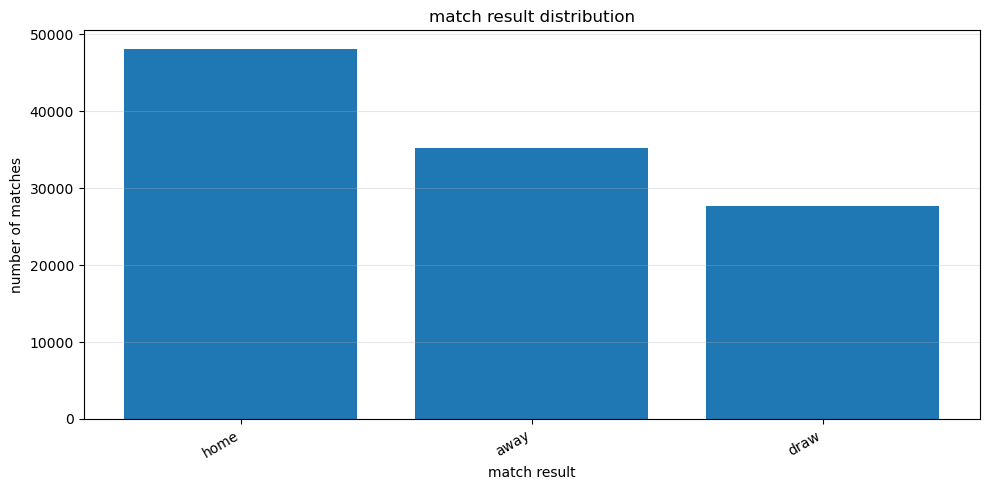

majority class:home
majority baseline accuracy :0.4337
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\class_balance_report.json


,majority_class,majority_baseline_accuracy,number_of_classes,target_missing_count,total_rows,valid_target_rows
0,home,0.433693,3,0,110938,110938


In [87]:
target_values = prepare_categorical_series(df_eda[TARGET_COL])

target_counts = target_values.value_counts(dropna=False)
target_percentage = target_values.value_counts(normalize=True,dropna=False).mul(100).round(2)



target_distribution = pd.DataFrame({
    'count': target_counts,
    'percentage': target_percentage
})

target_distribution.index.name = TARGET_COL


print('Target distribution')
print('*'*60)

display(target_distribution)

safe_save_csv(
    target_distribution.reset_index(),
    'target_distribution.csv',
    index=False
)

plot_bar(
    target_distribution['count'],
    title='match result distribution',
    xlabel='match result',
    ylabel='number of matches',
    filename='01_match_result_distribution.png',
    rotation=30
)

valid_target_values = df_eda[TARGET_COL].dropna()


if len(valid_target_values) >0 :
    valid_target_counts = valid_target_values.value_counts()
    
    
    majority_class = valid_target_counts.idxmax()
    majority_baseline_acccuracy = valid_target_counts.max()/ len(valid_target_values)
    
    print(f'majority class:{majority_class}')
    print(f'majority baseline accuracy :{majority_baseline_acccuracy:.4f}')
    
    
    class_balance_report = {
        'majority_class': str(majority_class),
        'majority_baseline_accuracy': float(majority_baseline_acccuracy),
        'number_of_classes':int(valid_target_counts.nunique()),
        'target_missing_count': int(df_eda[TARGET_COL].isna().sum()),
        'total_rows': int(len(df_eda)),
        'valid_target_rows': int(len(valid_target_values))
    }
    
    
    safe_save_json(class_balance_report,'class_balance_report.json')
    
    display(pd.DataFrame([class_balance_report]))
    
else:
    raise ValueError('target  column has no valid non-missing values')

fixture date analysis
********************************************************************************
original non-null fixture_date values: 110,938
successfully parsed fixture_date values :110,938
fixture date parse success:100.00%
minimum fixture date: 2019-12-01 00:45:00
maximum fixture date: 2021-05-01 00:00:00

matches by year


,year,matches_count
0,2019,6105
1,2020,71588
2,2021,33245


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\yearly_match_counts.csv
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\monthly_match_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\02_matches_by_year.png


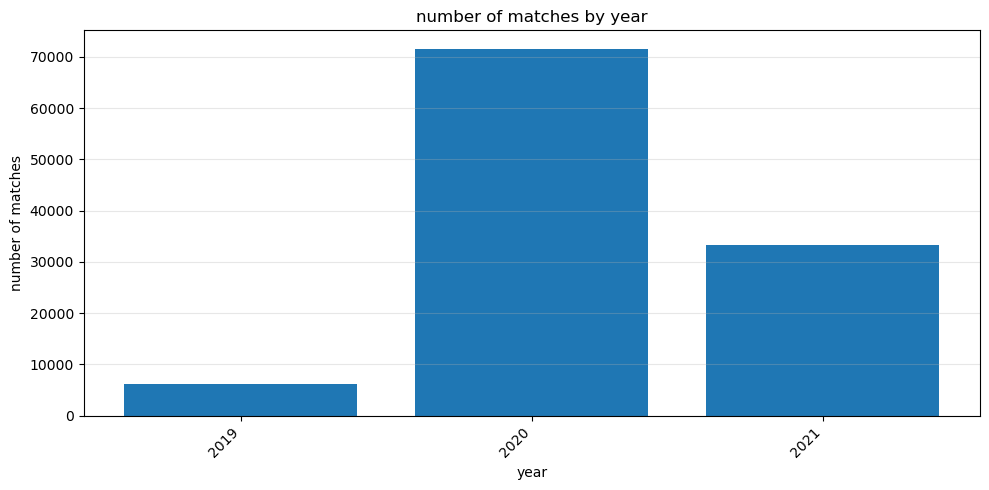

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\03_matches_by_month.png


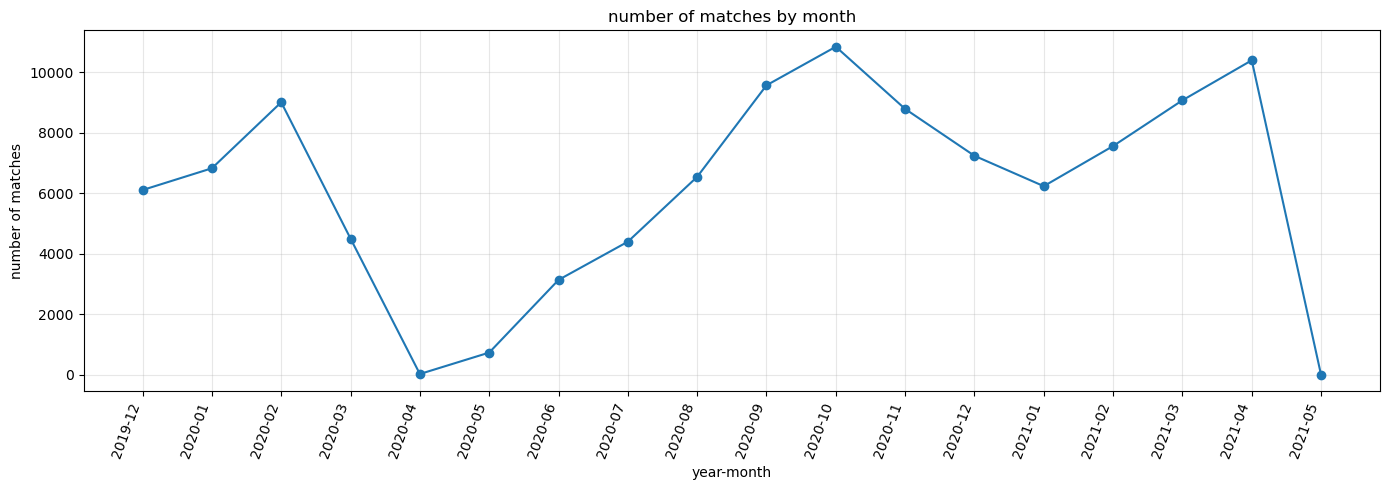

In [90]:

eda_df = df.copy()

if 'fixture_date' in eda_df.columns:
    eda_df['fixture_date_parsed'] = pd.to_datetime(
        eda_df['fixture_date'], errors='coerce'
    )
    
    original_non_null_dates = eda_df['fixture_date'].notna().sum()
    parsed_non_null_dates = eda_df['fixture_date_parsed'].notna().sum()
    
    
    if original_non_null_dates > 0:
        date_parse_success = parsed_non_null_dates / original_non_null_dates*100
    else:
        date_parse_success = 0
        
        
    print('fixture date analysis')
    print('*'*80)
    
    print(f'original non-null fixture_date values: {original_non_null_dates:,}')
    print(f'successfully parsed fixture_date values :{parsed_non_null_dates:,}')
    print(f'fixture date parse success:{date_parse_success:.2f}%')
    print(f'minimum fixture date: {eda_df['fixture_date_parsed'].min()}')
    print(f'maximum fixture date: {eda_df['fixture_date_parsed'].max()}')
    
    
    eda_df['fixture_year'] = eda_df['fixture_date_parsed'].dt.year
    eda_df['fixture_month'] = eda_df['fixture_date_parsed'].dt.month
    eda_df['fixture_year_month'] = eda_df['fixture_date_parsed'].dt.to_period('M').astype(str)
    
    
    valid_date_df = eda_df[eda_df['fixture_date_parsed'].notna()].copy()
    
    
    yearly_match_counts = (
        valid_date_df['fixture_year'].astype(int).value_counts().sort_index()
    )
    
    monthly_match_counts = (valid_date_df['fixture_year_month'].value_counts().sort_index())
    
    
    yearly_match_counts.name = 'matches_count'
    monthly_match_counts.name = 'matches_count'
    
    yearly_match_counts.index.name = 'year'
    monthly_match_counts.index.name = 'year_month'
    
    print("\nmatches by year")
    display(yearly_match_counts.reset_index())
    
    safe_save_csv(
            yearly_match_counts.reset_index(),
            'yearly_match_counts.csv',
            index=False
    )
    
    safe_save_csv(
        monthly_match_counts.reset_index(),
        'monthly_match_counts.csv',
        index=False
    )
    
    
    plot_bar(
        yearly_match_counts,
        title='number of matches by year',
        xlabel='year',
        ylabel='number of matches',
        filename='02_matches_by_year.png',
        rotation=45
    )
    
    
    
    if len(monthly_match_counts) <= 120:
        plot_line(
                monthly_match_counts,
                title='number of matches by month',
                xlabel='year-month',
                ylabel='number of matches',
                filename='03_matches_by_month.png',
                rotation=70,
                figsize=(14,5)
        )
    else:
        print("Monthly plot skipped because there are too many months to display clearly.")
else:
        print("fixture_date column does not exist. Skipping date analysis ")    

Competition distribution
------------------------------------------------------------


,matches_count,percentage
competition,,
Premier League,5565,5.02
Club Friendlies,3724,3.36
Primera Division,2369,2.14
Super League,1530,1.38
3. Liga,1327,1.20
Ligue 1,1210,1.09
Championship,1097,0.99
League One,1050,0.95
Superliga,1048,0.94


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\competition_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\04_top_competitions.png


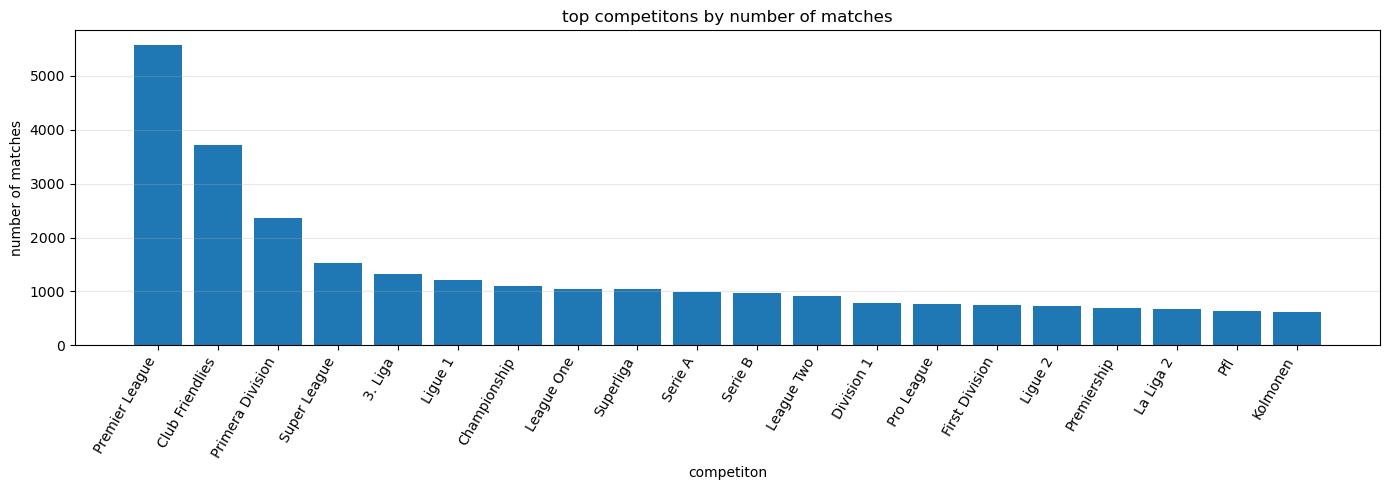


minimum matches required per competition : 554


match_result,away,draw,home,row_count
competition,,,,
Premier League,32.94,26.59,40.47,5565
Club Friendlies,31.23,22.72,46.05,3724
Primera Division,27.73,29.59,42.68,2369
Super League,28.63,28.56,42.81,1530
3. Liga,33.84,24.49,41.67,1327
Ligue 1,29.42,29.67,40.91,1210
Championship,33.55,26.34,40.11,1097
League One,31.81,25.90,42.29,1050
Superliga,31.87,25.76,42.37,1048


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\competition_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\05_target_distribution_by_competition.png


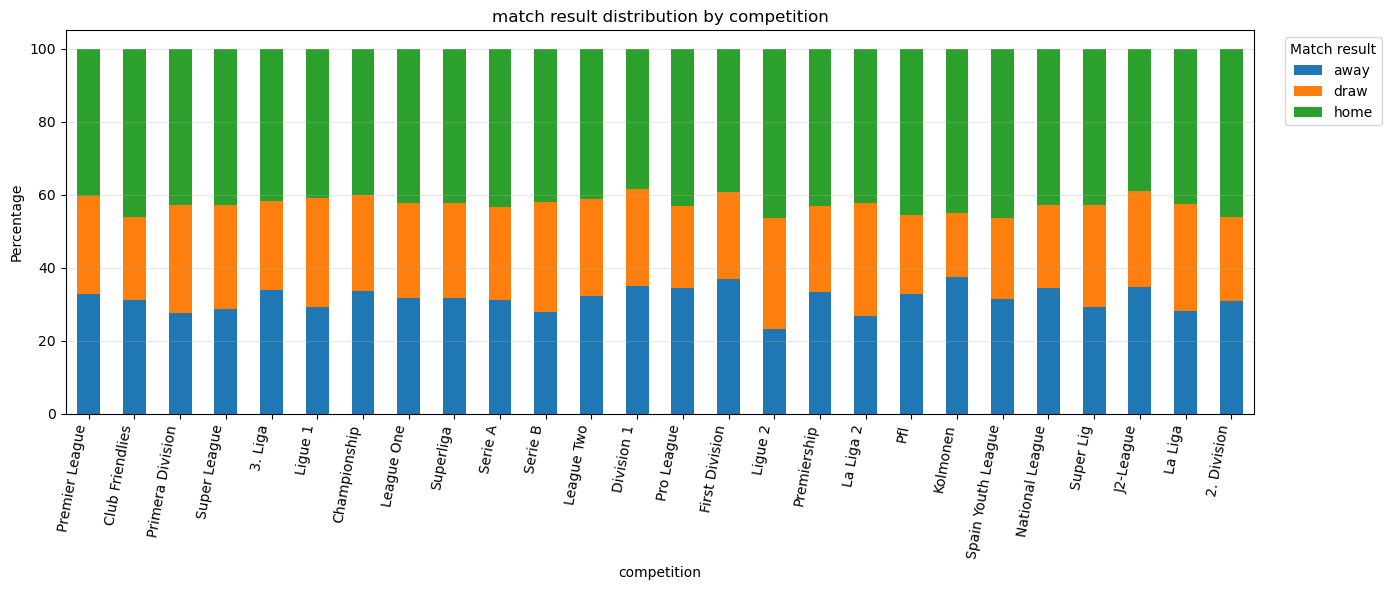

In [91]:
if 'competition' in eda_df.columns:
    competition_values = prepare_categorical_series(eda_df['competition'])
    
    competition_counts = competition_values.value_counts(dropna=False)
    competition_percentage = competition_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    competition_summary = pd.DataFrame({
        'matches_count': competition_counts,
        'precentage': competition_percentage
    })
    
    competition_summary = pd.DataFrame({
        'matches_count': competition_counts,
        'percentage': competition_percentage
    })
    
    
    competition_summary.index.name = 'competition'
    
    print('Competition distribution')
    print('-'*60)
    
    display(competition_summary.head(30))
    
    safe_save_csv(
            competition_summary.reset_index(),
            'competition_counts.csv',
            index=False
    )
    
    plot_bar(
        competition_counts.head(20),
        title='top competitons by number of matches',
        xlabel='competiton',
        ylabel='number of matches',
        filename='04_top_competitions.png',
        rotation=60,
        figsize=(14,5)
    )
    
    min_competition_count = max(20,int(len(eda_df)*0.005))
    
    competition_target_distribution = target_distribution_by_group(
        eda_df,group_col='competition',min_count=min_competition_count,target_col =TARGET_COL
    )
    
    
    print(f'\nminimum matches required per competition : {min_competition_count:,}')
    
    
    if not competition_target_distribution.empty:
        display(competition_target_distribution.head(30))
        
        safe_save_csv(
            competition_target_distribution.reset_index().rename(columns={'index':'competition'}),
            'competition_target_distribution.csv',
            index=False
        )
        
        plot_stacked_percentage(
            competition_target_distribution.drop(columns=['row_count']).head(30),
            title='match result distribution by competition',
            xlabel= 'competition',
            filename='05_target_distribution_by_competition.png',
            rotation=80,
            figsize=(14,6)
        )
    else:
        print('no competition group has enough records for target distribution analysis')
else:
    print("competition column does not exist. Skipping competition analysis.")

cup game distribution
------------------------------------------------------------


,count,percentage
cup_game,,
False,101856,91.81
True,9081,8.19
missing,1,0.00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\cup_game_distribution.csv

 target distribution by cup game:


match_result,away,draw,home
cup_game,,,
False,31.35,25.24,43.41
True,35.70,21.41,42.89
missing,100.00,0.00,0.00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\cup_game_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\06_target_distribution_by_cup_game.png


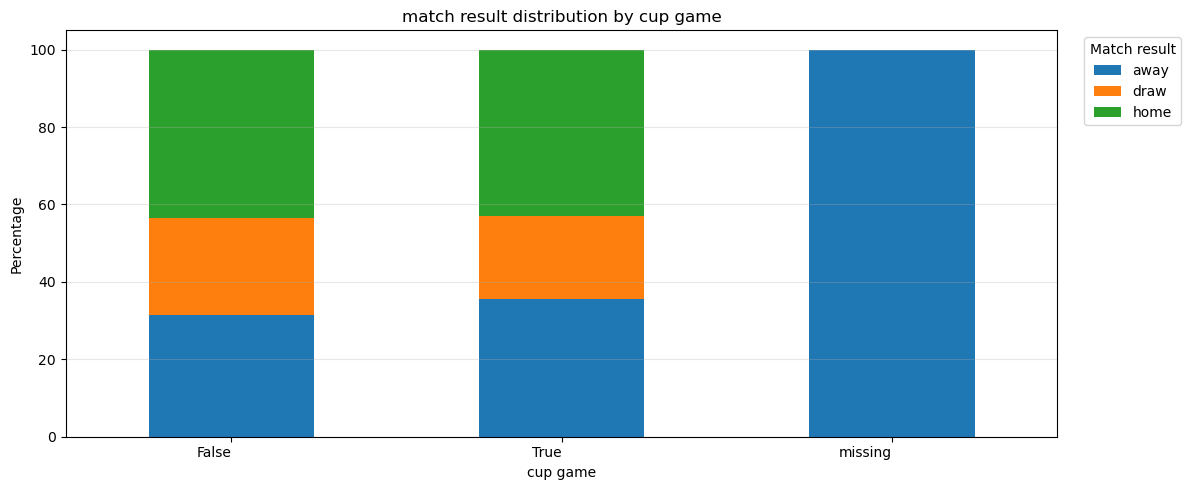

In [92]:
if 'cup_game' in eda_df.columns:
    cup_values = prepare_categorical_series(eda_df['cup_game'])
    
    
    cup_counts = cup_values.value_counts(dropna=False)
    cup_percentages = cup_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    cup_summary = pd.DataFrame({
        'count': cup_counts,
        'percentage': cup_percentages
    })
    
    cup_summary.index.name ='cup_game'
    
    print('cup game distribution')
    print('-'*60)
    
    display(cup_summary)
    
    
    safe_save_csv(
        cup_summary.reset_index(),
        'cup_game_distribution.csv',
        index=False
    )
    
    
    cup_target_distribution = crosstab_percentage(
        eda_df,
        row_col='cup_game',
        target_col=TARGET_COL
    )
    
    print('\n target distribution by cup game:')
    display(cup_target_distribution)
    
    
    safe_save_csv(
        cup_target_distribution.reset_index().rename(columns={'index':'cup_game'}),'cup_game_target_distribution.csv',index=False
    )
    
    
    plot_stacked_percentage(
        cup_target_distribution,
        title='match result distribution by cup game',
        xlabel='cup game',
        filename='06_target_distribution_by_cup_game.png',
        rotation=0
    )
    
else:
    print("cup_game column does not exist  Skipping cup game analysis ")